# Actividad 2 — Modelado predictivo con regresión: Student Performance Factors

## 1. Descripción del dataset

**Contexto:** el dataset reúne información académica, personal, familiar y escolar de estudiantes (horas de estudio, asistencia, calificaciones previas, involucramiento parental, acceso a recursos, calidad docente, entre otras variables) con el propósito de analizar qué factores se asocian con el desempeño en un examen.

> **Sobre la limpieza de datos:** todo el proceso de limpieza (revisión de duplicados, valores faltantes y tipos de dato) se realiza **dentro de este mismo notebook**, a partir del archivo crudo `StudentPerformanceFactors.csv`. No se entregan archivos "ya limpios" generados por fuera del código: el único CSV adicional que produce este notebook es `student_performance_factors_processed.csv`, generado por la celda de la sección 2, de modo que el procedimiento completo quede documentado y sea reproducible.

**Unidad de análisis:** cada registro representa a un estudiante, describiendo sus características académicas, personales, familiares y del entorno escolar.

**Variable objetivo:** `Exam_Score` (puntaje numérico obtenido en el examen).

**Pregunta predictiva que guía el análisis:** ¿en qué medida las características académicas, personales y escolares de los estudiantes permiten estimar su puntaje de examen mediante modelos de regresión?


In [5]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Carga del dataset y revisión inicial

Se carga el archivo original `StudentPerformanceFactors.csv` y se revisa su estructura: número de registros, variables, tipos de dato, valores faltantes y duplicados. Este es el mismo archivo trabajado en la Actividad 1; aquí se verifica explícitamente que se puede cargar sin errores.


In [7]:
df_raw = pd.read_csv('/content/drive/MyDrive/Algoritmos de AA/CSV/StudentPerformanceFactors.csv')
print(f"Registros: {df_raw.shape[0]}   Columnas: {df_raw.shape[1]}")
df_raw.head()


Registros: 6607   Columnas: 20


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [8]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [9]:
# Valores faltantes por columna
missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columnas con valores faltantes:")
print(missing)

# Duplicados
n_dup = df_raw.duplicated().sum()
print(f"\nRegistros duplicados: {n_dup}")


Columnas con valores faltantes:
Parental_Education_Level    90
Teacher_Quality             78
Distance_from_Home          67
dtype: int64

Registros duplicados: 0


### Limpieza aplicada

Con base en la revisión anterior (celda previa) se aplican únicamente las transformaciones necesarias para el modelado, todas ejecutadas en la siguiente celda de código:

1. **Eliminación de duplicados exactos**, en caso de existir: no aportan información nueva y podrían sesgar la evaluación si quedaran repartidos entre entrenamiento y prueba.
2. **No se eliminan registros por valores faltantes**: las columnas con NaN (`Teacher_Quality`, `Parental_Education_Level`, `Distance_from_Home`) representan un porcentaje muy bajo de los datos cada una; se manejarán mediante **imputación** dentro del pipeline de preprocesamiento (sección 5), para no perder información y para que la imputación se ajuste únicamente con el conjunto de entrenamiento (evitando fuga de información).
3. **Verificación de tipos de dato**: las columnas numéricas (`Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`, `Physical_Activity`, `Exam_Score`) ya están correctamente tipadas como enteros; las categóricas permanecen como texto (`object`) para ser codificadas más adelante.
4. Se guarda el resultado de este proceso como `student_performance_factors_processed.csv`, el archivo procesado que se entrega junto con este notebook.


In [10]:
n_antes = df_raw.shape[0]
df = df_raw.drop_duplicates().reset_index(drop=True)
n_despues = df.shape[0]
print(f"Registros antes de limpieza: {n_antes}")
print(f"Duplicados eliminados: {n_antes - n_despues}")
print(f"Registros después de limpieza: {n_despues}")

# Verificación de tipos de dato tras la limpieza
print("\nTipos de dato:")
print(df.dtypes)

# Se guarda el archivo procesado (post-eliminación de duplicados; la imputación
# de valores faltantes se hace dentro del pipeline de la sección 5, no aquí,
# para evitar fuga de información desde el conjunto de prueba)
df.to_csv('student_performance_factors_processed.csv', index=False)
print("\nArchivo procesado guardado como 'student_performance_factors_processed.csv'")


Registros antes de limpieza: 6607
Duplicados eliminados: 0
Registros después de limpieza: 6607

Tipos de dato:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

Archivo procesado guardado como 'student_performance_factors_processed.csv'


## 3. Exploración de la variable objetivo (`Exam_Score`)


count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


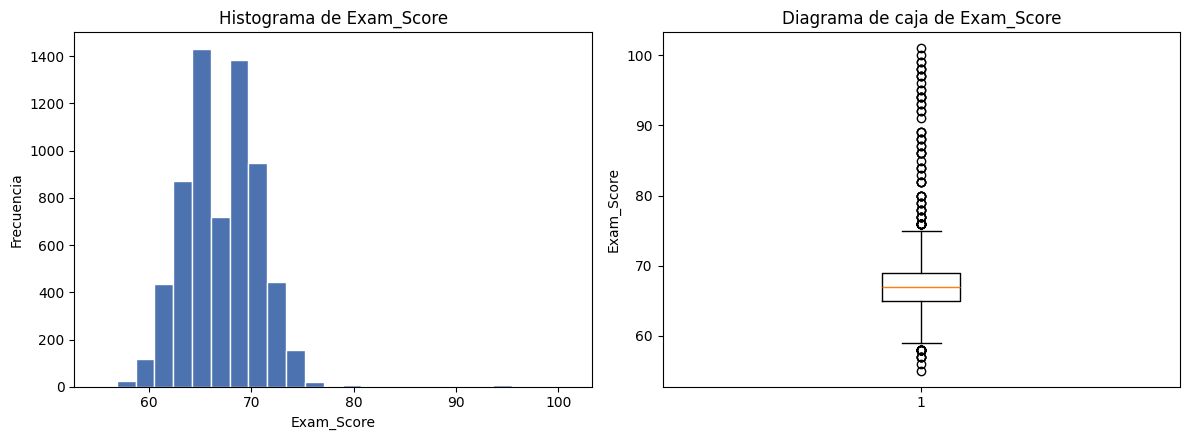

In [11]:
print(df['Exam_Score'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df['Exam_Score'], bins=25, color='#4C72B0', edgecolor='white')
axes[0].set_title('Histograma de Exam_Score')
axes[0].set_xlabel('Exam_Score')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['Exam_Score'], vert=True)
axes[1].set_title('Diagrama de caja de Exam_Score')
axes[1].set_ylabel('Exam_Score')

plt.tight_layout()
plt.show()


**Lectura rápida:** `Exam_Score` tiene una media de 67.2 y una desviación estándar de solo 3.9 puntos, con la mayoría de los estudiantes (percentiles 25–75) entre 65 y 69. Sin embargo, el máximo llega a 101, muy por encima del rango típico: en el diagrama de caja aparece un número reducido pero visible de estudiantes con puntajes altos que se comportan como valores atípicos respecto al resto del grupo. Esto sugiere que, aunque el desempeño de la mayoría de los estudiantes es bastante homogéneo, existe un pequeño grupo con resultados excepcionalmente altos que conviene tener presente en el análisis de errores más adelante (sección 10).


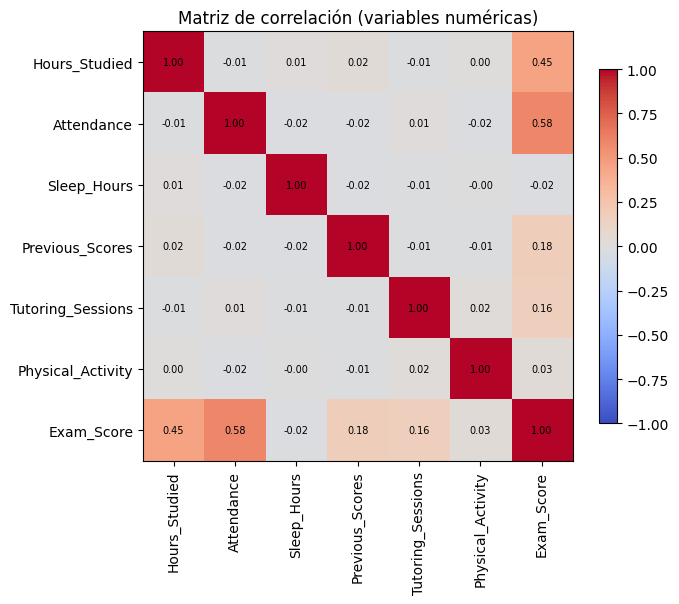

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

print(corr['Exam_Score'].sort_values(ascending=False))


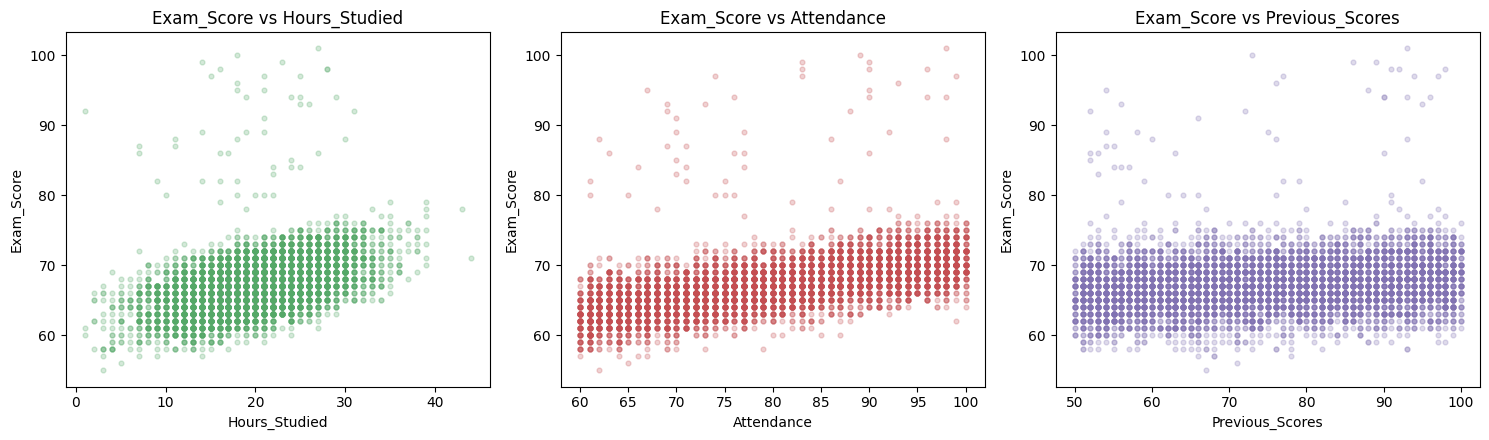

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].scatter(df['Hours_Studied'], df['Exam_Score'], alpha=0.25, s=12, color='#55A868')
axes[0].set_xlabel('Hours_Studied'); axes[0].set_ylabel('Exam_Score')
axes[0].set_title('Exam_Score vs Hours_Studied')

axes[1].scatter(df['Attendance'], df['Exam_Score'], alpha=0.25, s=12, color='#C44E52')
axes[1].set_xlabel('Attendance'); axes[1].set_ylabel('Exam_Score')
axes[1].set_title('Exam_Score vs Attendance')

axes[2].scatter(df['Previous_Scores'], df['Exam_Score'], alpha=0.25, s=12, color='#8172B2')
axes[2].set_xlabel('Previous_Scores'); axes[2].set_ylabel('Exam_Score')
axes[2].set_title('Exam_Score vs Previous_Scores')

plt.tight_layout()
plt.show()


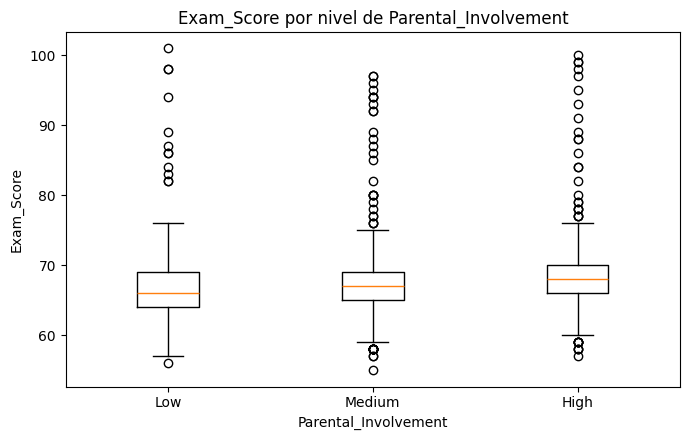

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
groups = [df.loc[df['Parental_Involvement'] == lvl, 'Exam_Score'] for lvl in ['Low', 'Medium', 'High']]
ax.boxplot(groups, tick_labels=['Low', 'Medium', 'High'])
ax.set_xlabel('Parental_Involvement')
ax.set_ylabel('Exam_Score')
ax.set_title('Exam_Score por nivel de Parental_Involvement')
plt.tight_layout()
plt.show()


### Selección de variables para el modelado

A partir de la matriz de correlación se observa que `Attendance` (r ≈ 0.58) y `Hours_Studied` (r ≈ 0.45) son, por mucho, los predictores numéricos con mayor relación lineal con `Exam_Score`; `Previous_Scores` (r ≈ 0.18) y `Tutoring_Sessions` (r ≈ 0.16) muestran una relación positiva más moderada, mientras que `Sleep_Hours` y `Physical_Activity` prácticamente no se correlacionan con el puntaje (r cercano a 0). En las variables categóricas, el diagrama de caja muestra que un `Parental_Involvement` más alto se asocia con una mediana de `Exam_Score` ligeramente mayor (68 vs. 66 puntos entre "High" y "Low"). Con base en esta evidencia, se seleccionan las siguientes variables predictoras:

- **Numéricas:** `Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`, `Physical_Activity`
- **Categóricas nominales:** `Extracurricular_Activities`, `Internet_Access`, `School_Type`, `Peer_Influence`, `Learning_Disabilities`, `Gender`, `Distance_from_Home`
- **Categóricas ordinales** (tienen un orden natural Low < Medium < High): `Parental_Involvement`, `Access_to_Resources`, `Motivation_Level`, `Family_Income`, `Teacher_Quality`

Se excluye `Parental_Education_Level` del conjunto de variables por simplicidad del primer modelo (alto porcentaje de categorías y relación débil observada), aunque podría incorporarse en una iteración posterior.


In [15]:
numeric_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
                    'Tutoring_Sessions', 'Physical_Activity']

nominal_features = ['Extracurricular_Activities', 'Internet_Access', 'School_Type',
                     'Peer_Influence', 'Learning_Disabilities', 'Gender', 'Distance_from_Home']

ordinal_features = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level',
                     'Family_Income', 'Teacher_Quality']

ordinal_categories = [
    ['Low', 'Medium', 'High'],   # Parental_Involvement
    ['Low', 'Medium', 'High'],   # Access_to_Resources
    ['Low', 'Medium', 'High'],   # Motivation_Level
    ['Low', 'Medium', 'High'],   # Family_Income
    ['Low', 'Medium', 'High'],   # Teacher_Quality
]

feature_cols = numeric_features + nominal_features + ordinal_features
X = df[feature_cols].copy()
y = df['Exam_Score'].copy()

print(f"X: {X.shape}    y: {y.shape}")


X: (6607, 18)    y: (6607,)


## 4. División en entrenamiento y prueba

Se utiliza una proporción 80% / 20% y una **semilla fija** (`RANDOM_STATE = 42`). La semilla debe conservarse (y no cambiarse entre ejecuciones) para que la división sea **reproducible**: usar la misma semilla garantiza que cualquier persona que ejecute este notebook obtenga exactamente los mismos conjuntos de entrenamiento y prueba, lo que permite comparar resultados de forma justa y depurar el análisis sin que la variabilidad provenga de una partición distinta de los datos.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Entrenamiento: {X_train.shape[0]} registros   Prueba: {X_test.shape[0]} registros")


Entrenamiento: 5285 registros   Prueba: 1322 registros


## 5. Pipeline de preprocesamiento

Se construye un `ColumnTransformer` que aplica, de forma reproducible:

- **Numéricas:** imputación por mediana + escalamiento estándar (`StandardScaler`).
- **Categóricas nominales:** imputación por moda + `OneHotEncoder`.
- **Categóricas ordinales:** imputación por moda + `OrdinalEncoder` respetando el orden Low < Medium < High.

Todas las transformaciones se ajustan (`fit`) **únicamente con `X_train`**; el pipeline se limita a aplicar (`transform`) esas mismas reglas sobre `X_test`, evitando así fuga de información desde el conjunto de prueba.


In [17]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=ordinal_categories)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('nom', nominal_transformer, nominal_features),
    ('ord', ordinal_transformer, ordinal_features),
])
print(preprocessor)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                                  'Previous_Scores', 'Tutoring_Sessions',
                                  'Physical_Activity']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='i...
                                  'Gender', 'Distance_from_Home']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
               

## 6. Línea base

Antes de entrenar modelos "reales", se construye una línea base con `DummyRegressor` que siempre predice la **mediana** de `Exam_Score` en el conjunto de entrenamiento. Sirve como referencia mínima: cualquier modelo entrenado debería superarla claramente para justificar su uso.


In [18]:
def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

baseline_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='median')),
])
baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)
metrics_base = evaluar(y_test, y_pred_base)
metrics_base


{'MAE': 2.8078668683812404,
 'RMSE': 3.7730632185847637,
 'R2': -0.007140648098822755}

## 7. Entrenamiento de los modelos

**Modelo 1 — Regresión lineal:** modelo simple e interpretable, útil como primera aproximación cuantitativa a la relación entre los predictores y `Exam_Score`.

**Modelo 2 — Árbol de regresión (alternativa no lineal):** un `DecisionTreeRegressor` puede capturar relaciones no lineales e interacciones entre variables que la regresión lineal no modela directamente, lo que permite comparar un enfoque lineal contra uno basado en particiones del espacio de predictores. Se limita su profundidad (`max_depth`) para reducir el sobreajuste.

Ambos modelos utilizan exactamente el mismo `X_train` / `X_test` y el mismo preprocesador (dentro de su propio pipeline) para que la comparación sea consistente.


In [19]:
linreg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression()),
])
linreg_pipe.fit(X_train, y_train)
y_pred_lin = linreg_pipe.predict(X_test)
metrics_lin = evaluar(y_test, y_pred_lin)
metrics_lin


{'MAE': 0.5769034184237308,
 'RMSE': 1.8453632762420467,
 'R2': 0.7590839645290763}

In [20]:
tree_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE)),
])
tree_pipe.fit(X_train, y_train)
y_pred_tree = tree_pipe.predict(X_test)
metrics_tree = evaluar(y_test, y_pred_tree)
metrics_tree


{'MAE': 1.5911074674483379,
 'RMSE': 2.533707641632724,
 'R2': 0.5458336400110277}

## 8. Tabla comparativa de métricas


In [21]:
tabla_metricas = pd.DataFrame({
    'Modelo': ['Línea base', 'Regresión lineal', 'Árbol de regresión (alternativo)'],
    'MAE': [metrics_base['MAE'], metrics_lin['MAE'], metrics_tree['MAE']],
    'RMSE': [metrics_base['RMSE'], metrics_lin['RMSE'], metrics_tree['RMSE']],
    'R2': [metrics_base['R2'], metrics_lin['R2'], metrics_tree['R2']],
}).round(3)
tabla_metricas


,Modelo,MAE,RMSE,R2
0,Línea base,2.808,3.773,-0.007
1,Regresión lineal,0.577,1.845,0.759
2,Árbol de regresión (alternativo),1.591,2.534,0.546


### Interpretación de las métricas

Con el conjunto de prueba, la **línea base** (predecir siempre la mediana) obtiene MAE ≈ 2.81, RMSE ≈ 3.77 y R² ≈ -0.01 (esencialmente cero o ligeramente negativo, como se espera de un modelo que no usa ninguna variable predictora). La **regresión lineal** reduce el MAE a ≈ 0.58 puntos, el RMSE a ≈ 1.85 puntos y alcanza un R² ≈ 0.76. El **árbol de regresión** queda en un punto intermedio (MAE ≈ 1.59, RMSE ≈ 2.53, R² ≈ 0.55).

- **MAE (error absoluto medio):** con la regresión lineal, un MAE de ≈ 0.58 significa que, en promedio, la predicción de `Exam_Score` se aleja apenas poco más de medio punto del valor real — un margen pequeño si se considera que la propia variable tiene una desviación estándar de solo ≈ 3.9 puntos. Esto indica un ajuste bastante preciso para la mayoría de los estudiantes.
- **RMSE (raíz del error cuadrático medio):** al elevar los errores al cuadrado antes de promediarlos, penaliza con mayor intensidad los errores grandes. Que el RMSE (≈ 1.85) sea claramente mayor que el MAE (≈ 0.58) en la regresión lineal confirma que, aunque la mayoría de los estudiantes se predice con un error muy pequeño, existe un grupo reducido de casos —probablemente los mismos con puntajes atípicamente altos identificados en la sección 3— cuyo error es mucho mayor y "eleva" el RMSE de forma desproporcionada.
- **R² (coeficiente de determinación):** un R² ≈ 0.76 en la regresión lineal indica que las variables seleccionadas (sobre todo asistencia, horas de estudio, calificaciones previas y tutorías) explican aproximadamente tres cuartas partes de la variabilidad de `Exam_Score`, frente a un R² ≈ 0 de la línea base. El 24% restante de la variabilidad queda sin explicar por estas variables, probablemente por factores no medidos (estado del estudiante el día del examen, dificultad específica de las preguntas, etc.), y de forma particular por el pequeño grupo de estudiantes con puntajes muy altos que el modelo no logra anticipar bien (ver sección 10).

En este caso, la regresión lineal superó claramente al árbol de regresión y a la línea base en las tres métricas, lo que sugiere que la relación entre los predictores seleccionados y `Exam_Score` es, en su mayor parte, aproximadamente lineal; el árbol, al particionar el espacio de predictores en regiones, pierde parte de esa relación continua y termina generalizando peor en este conjunto de datos.


## 9. Valores reales vs. predichos y análisis de residuos


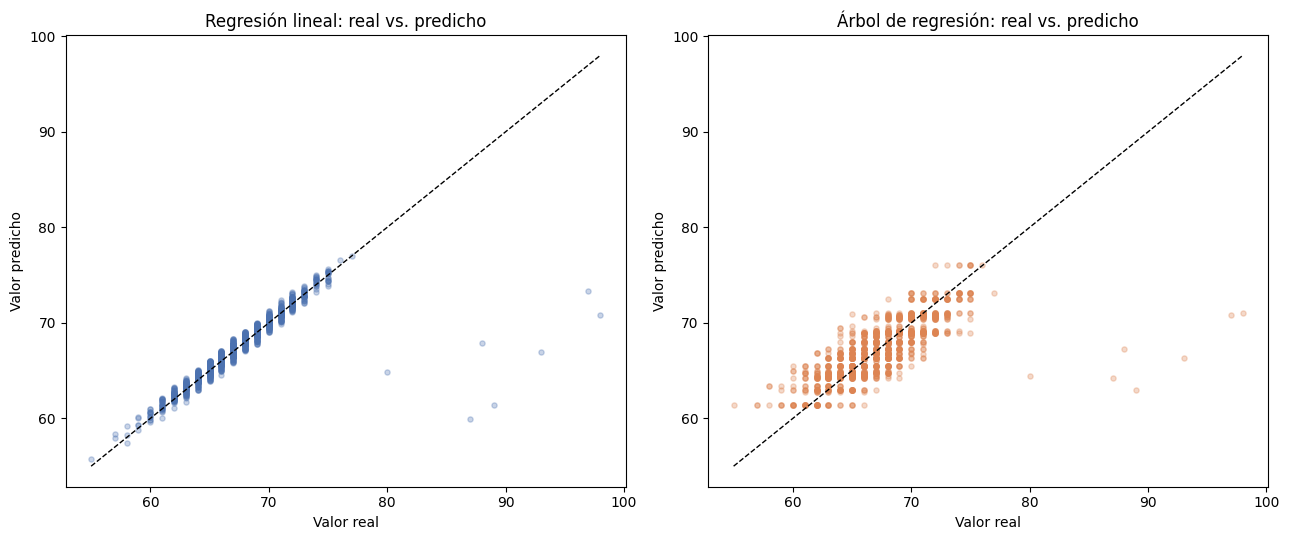

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(y_test, y_pred_lin, alpha=0.3, s=14, color='#4C72B0')
lims = [min(y_test.min(), y_pred_lin.min()), max(y_test.max(), y_pred_lin.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1)
axes[0].set_xlabel('Valor real'); axes[0].set_ylabel('Valor predicho')
axes[0].set_title('Regresión lineal: real vs. predicho')

axes[1].scatter(y_test, y_pred_tree, alpha=0.3, s=14, color='#DD8452')
lims2 = [min(y_test.min(), y_pred_tree.min()), max(y_test.max(), y_pred_tree.max())]
axes[1].plot(lims2, lims2, 'k--', linewidth=1)
axes[1].set_xlabel('Valor real'); axes[1].set_ylabel('Valor predicho')
axes[1].set_title('Árbol de regresión: real vs. predicho')

plt.tight_layout()
plt.show()


Modelo con mejor desempeño: Regresión lineal


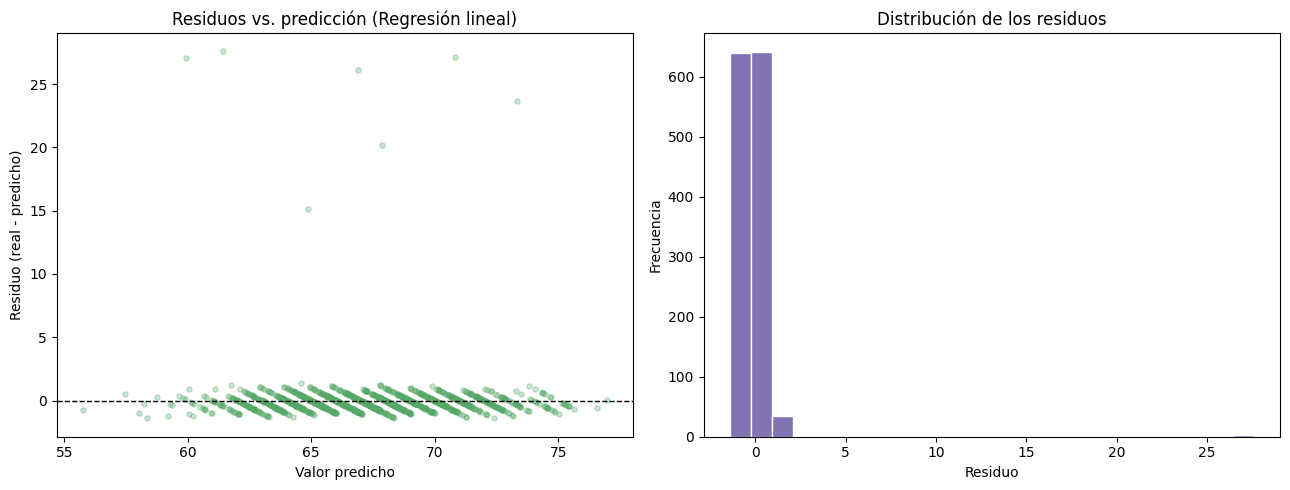

Media de los residuos: -0.044   Desv. estándar: 1.845


In [23]:
# Se elige el modelo con mejor desempeño (mayor R2 / menor RMSE) para el análisis de residuos
mejor_nombre = 'Regresión lineal' if metrics_lin['R2'] >= metrics_tree['R2'] else 'Árbol de regresión'
y_pred_mejor = y_pred_lin if mejor_nombre == 'Regresión lineal' else y_pred_tree
print(f"Modelo con mejor desempeño: {mejor_nombre}")

residuos = y_test.values - y_pred_mejor

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred_mejor, residuos, alpha=0.3, s=14, color='#55A868')
axes[0].axhline(0, color='k', linestyle='--', linewidth=1)
axes[0].set_xlabel('Valor predicho'); axes[0].set_ylabel('Residuo (real - predicho)')
axes[0].set_title(f'Residuos vs. predicción ({mejor_nombre})')

axes[1].hist(residuos, bins=25, color='#8172B2', edgecolor='white')
axes[1].set_xlabel('Residuo'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de los residuos')

plt.tight_layout()
plt.show()

print(f"Media de los residuos: {residuos.mean():.3f}   Desv. estándar: {residuos.std():.3f}")


**Lectura del análisis de residuos:** para la mayoría de los estudiantes, los residuos están prácticamente pegados a cero (desviación estándar ≈ 1.85), lo cual es consistente con un R² alto. Sin embargo, la dispersión de los residuos crece notoriamente entre los estudiantes con `Exam_Score` predicho más alto: ahí aparecen los residuos más grandes en magnitud, casi siempre subestimando el puntaje real (el modelo predice menos de lo que el estudiante realmente obtuvo). Esto sugiere que el modelo tiene dificultad específicamente para anticipar a los estudiantes con desempeño excepcionalmente alto, probablemente porque su puntaje está influido por factores no capturados por las variables disponibles (motivación puntual, condiciones del día del examen, etc.) y porque hay relativamente pocos casos así en los datos de entrenamiento para que el modelo aprenda ese patrón.


## 10. Casos con mayor y menor error absoluto


In [24]:
resultados_test = X_test.copy()
resultados_test['Exam_Score_real'] = y_test.values
resultados_test['Exam_Score_predicho'] = np.round(y_pred_mejor, 1)
resultados_test['error_absoluto'] = np.abs(resultados_test['Exam_Score_real'] - resultados_test['Exam_Score_predicho'])

cols_mostrar = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions',
                'Parental_Involvement', 'Access_to_Resources',
                'Exam_Score_real', 'Exam_Score_predicho', 'error_absoluto']

print("Casos con MAYOR error absoluto:")
display(resultados_test.sort_values('error_absoluto', ascending=False)[cols_mostrar].head(5))

print("\nCasos con MENOR error absoluto:")
display(resultados_test.sort_values('error_absoluto', ascending=True)[cols_mostrar].head(5))


Casos con MAYOR error absoluto:


,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Parental_Involvement,Access_to_Resources,Exam_Score_real,Exam_Score_predicho,error_absoluto
217,19,70,54,0,Medium,Low,89,61.4,27.6
4192,28,90,91,0,Low,Medium,98,70.8,27.2
2687,11,71,55,1,Low,Medium,87,59.9,27.1
4531,26,69,95,0,High,High,93,66.9,26.1
5966,25,99,77,0,Medium,Medium,97,73.3,23.7



Casos con MENOR error absoluto:


,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Parental_Involvement,Access_to_Resources,Exam_Score_real,Exam_Score_predicho,error_absoluto
4690,20,71,92,1,Medium,Low,65,65.0,0.0
5385,20,98,80,0,Medium,Medium,70,70.0,0.0
2955,30,98,51,0,Low,Medium,71,71.0,0.0
6308,20,68,80,4,Low,Medium,65,65.0,0.0
2531,14,84,81,0,Medium,Medium,66,66.0,0.0


**Comparación:** los cinco casos con mayor error absoluto tienen en común un `Exam_Score` real muy alto (87 a 98 puntos) combinado con horas de estudio, asistencia y calificaciones previas apenas moderadas —perfiles que, según el patrón general del resto de los datos, no anticipan un puntaje tan alto—. El modelo, apegado al comportamiento típico de la mayoría, predice para estos estudiantes un puntaje mucho más cercano al promedio (61–73), subestimando el resultado real por 24 a 28 puntos. En contraste, los casos con menor error absoluto (error de 0.0) corresponden a estudiantes con puntajes dentro del rango típico (65–71), donde las variables predictoras siguen el patrón general de la mayoría de los datos.

Esto sugiere que el error no proviene de un problema de preprocesamiento ni del pipeline, sino de una **limitación de las variables disponibles** frente a un pequeño grupo de estudiantes "atípicos": existen probablemente factores individuales (motivación puntual, condiciones específicas el día del examen, dificultad percibida de las preguntas) que no están representados en el dataset y que explican por qué algunos estudiantes con perfiles "esperables" logran resultados excepcionalmente altos que el modelo no anticipa.


## 11. Validación cruzada k-fold


In [25]:
mejor_pipe = linreg_pipe if mejor_nombre == 'Regresión lineal' else tree_pipe

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2 = cross_val_score(mejor_pipe, X_train, y_train, cv=kf, scoring='r2')
cv_neg_rmse = cross_val_score(mejor_pipe, X_train, y_train, cv=kf,
                               scoring='neg_root_mean_squared_error')
cv_rmse = -cv_neg_rmse

print(f"R2 por partición: {np.round(cv_r2, 3)}")
print(f"R2 promedio: {cv_r2.mean():.3f}   Desviación estándar: {cv_r2.std():.3f}")
print()
print(f"RMSE por partición: {np.round(cv_rmse, 3)}")
print(f"RMSE promedio: {cv_rmse.mean():.3f}   Desviación estándar: {cv_rmse.std():.3f}")
print()
print(f"Comparación con la única partición de prueba usada antes ({mejor_nombre}):")
print(f"  R2 (partición única):   {metrics_lin['R2'] if mejor_nombre=='Regresión lineal' else metrics_tree['R2']:.3f}")
print(f"  RMSE (partición única): {metrics_lin['RMSE'] if mejor_nombre=='Regresión lineal' else metrics_tree['RMSE']:.3f}")


R2 por partición: [0.701 0.709 0.761 0.657 0.708]
R2 promedio: 0.707   Desviación estándar: 0.033

RMSE por partición: [2.076 2.179 1.824 2.381 2.14 ]
RMSE promedio: 2.120   Desviación estándar: 0.180

Comparación con la única partición de prueba usada antes (Regresión lineal):
  R2 (partición única):   0.759
  RMSE (partición única): 1.845


**¿Por qué la validación cruzada ofrece una referencia más estable?** Con una sola partición de entrenamiento/prueba, el valor de la métrica depende en parte de qué registros "cayeron" por azar en el conjunto de prueba; un conjunto de prueba particularmente fácil o difícil puede hacer ver al modelo mejor o peor de lo que realmente es. La validación cruzada k-fold entrena y evalúa el modelo **cinco veces**, usando en cada ocasión una porción distinta de los datos de entrenamiento como validación, por lo que la métrica final es un **promedio sobre varias particiones** y viene acompañada de una desviación estándar que indica qué tanto varía el desempeño según los datos usados. Esto reduce la dependencia de una única división "afortunada o desafortunada" y ofrece una estimación más confiable del desempeño esperado del modelo con datos nuevos. La validación cruzada se aplicó únicamente sobre `X_train` / `y_train`, dentro del mismo pipeline (que ajusta el preprocesamiento en cada fold por separado), evitando así fuga de información del conjunto de prueba.


## 12. Conclusión

- **Modelo con mejores resultados:** la **regresión lineal** obtuvo el mejor desempeño en el conjunto de prueba (MAE ≈ 0.58, RMSE ≈ 1.85, R² ≈ 0.76), superando claramente al árbol de regresión (MAE ≈ 1.59, RMSE ≈ 2.53, R² ≈ 0.55).
- **Mejora respecto a la línea base:** la línea base (predecir siempre la mediana de `Exam_Score`) obtuvo R² ≈ -0.01, es decir, prácticamente ninguna capacidad explicativa. La regresión lineal representa una mejora sustancial: reduce el MAE en más de 2 puntos (de ≈ 2.81 a ≈ 0.58) y pasa de un R² cercano a cero a uno de ≈ 0.76, lo que confirma que las variables seleccionadas —especialmente asistencia, horas de estudio, calificaciones previas y sesiones de tutoría— aportan información real y sustancial para estimar el puntaje de examen.
- **Variables que parecieron más relevantes:** de acuerdo con la matriz de correlación, `Attendance` (r ≈ 0.58) y `Hours_Studied` (r ≈ 0.45) fueron, por amplio margen, los predictores numéricos con relación más fuerte con `Exam_Score`, seguidos de `Previous_Scores` y `Tutoring_Sessions` (r ≈ 0.16–0.18). `Parental_Involvement` mostró una relación más moderada pero visible (mediana de `Exam_Score` de 68 en el nivel "High" frente a 66 en "Low"). `Sleep_Hours` y `Physical_Activity` no mostraron relación relevante con el desempeño en el examen.
- **Limitaciones identificadas:** (1) el análisis de residuos y la revisión de casos con mayor error absoluto (sección 10) mostraron que el modelo tiene mucha mayor dificultad para predecir a los estudiantes con puntajes atípicamente altos (por ejemplo, `Exam_Score` > 85), donde el error puede superar los 25 puntos, mientras que para la mayoría de los estudiantes "típicos" el error es prácticamente nulo; (2) el buen desempeño global (R² ≈ 0.76) está dominado por este comportamiento homogéneo de la mayoría de los casos, por lo que el modelo, tal como está, no debería usarse para identificar o intervenir en los pocos estudiantes con desempeño excepcional; (3) es probable que existan variables no incluidas en el dataset (estado emocional o de salud el día del examen, dificultad específica de las preguntas, motivación puntual) que explican por qué ese pequeño grupo se aleja tanto del patrón general.
- **Propuesta de mejora para una etapa posterior:** probar modelos de ensamble (por ejemplo, Random Forest o Gradient Boosting) que puedan capturar mejor tanto la relación lineal dominante como los casos atípicos; realizar una búsqueda de hiperparámetros más sistemática (`GridSearchCV`) para el árbol o para una versión regularizada (Ridge/Lasso); e investigar de forma específica el subgrupo de estudiantes con `Exam_Score` alto para entender si comparten alguna característica no capturada por las variables actuales.
- **¿Es suficiente como primera aproximación?** Sí: el modelo de regresión lineal demuestra de forma contundente que existe una relación fuerte y aprovechable entre las características disponibles (sobre todo asistencia y horas de estudio) y el puntaje de examen, y establece una línea base cuantitativa sólida. Sin embargo, dado que su error se concentra fuertemente en los estudiantes con desempeño atípico, **no se considera suficiente todavía para apoyar decisiones académicas individuales** sobre esos casos particulares (por ejemplo, identificar a un estudiante en riesgo o con potencial excepcional) sin una validación adicional y un análisis específico de ese subgrupo.
